In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn openpyxl

# ***SUPERVISED LEARNING***

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


import joblib


In [3]:
df1 = pd.read_csv("solar_iq_pakistan_dataset_noisy_10k.csv")

df1.head()
df1.shape
df1.isnull().sum()

,0
city,0
location_code,0
daily_energy_consumption_kwh,0
roof_area_sqm,0
load_shedding_hours,0
solar_irradiance_kwh_per_m2,0
sun_hours,0
avg_temp_c,0
recommended_system_size_kw,0
estimated_cost_pkr,0


In [4]:
le_city = LabelEncoder()
df1['city_encoded'] = le_city.fit_transform(df1['city'])

In [5]:
le_location = LabelEncoder()
df1['location_code_encoded'] = le_location.fit_transform(df1['location_code'])
df1[['location_code', 'location_code_encoded']].head()

,location_code,location_code_encoded
0,QTA,7
1,QTA,7
2,BWP,0
3,KHI,3
4,KHI,3


In [6]:
X = df1[
    ['city_encoded',
     'location_code_encoded',
     'daily_energy_consumption_kwh',
     'roof_area_sqm',
     'load_shedding_hours',
     'solar_irradiance_kwh_per_m2',
     'sun_hours',
     'avg_temp_c']
]

y_size = df1['recommended_system_size_kw']
y_cost = df1['estimated_cost_pkr']


In [7]:
X_train, X_test, y_size_train, y_size_test = train_test_split(
    X, y_size, test_size=0.2, random_state=42
)

_, _, y_cost_train, y_cost_test = train_test_split(
    X, y_cost, test_size=0.2, random_state=42
)


In [8]:
gb_size = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)

gb_size.fit(X_train, y_size_train)


GradientBoostingRegressor(learning_rate=0.08, n_estimators=200, random_state=42)

In [9]:
size_pred = gb_size.predict(X_test)

print("System Size R2:", r2_score(y_size_test, size_pred))
print("System Size MAE:", mean_absolute_error(y_size_test, size_pred))


System Size R2: 0.9776735742635286
System Size MAE: 0.18142963192248915


In [10]:
gb_cost = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)

gb_cost.fit(X_train, y_cost_train)


GradientBoostingRegressor(learning_rate=0.08, n_estimators=200, random_state=42)

In [11]:
cost_pred = gb_cost.predict(X_test)

print("Cost R2:", r2_score(y_cost_test, cost_pred))
print("Cost MAE:", mean_absolute_error(y_cost_test, cost_pred))


Cost R2: 0.9776484603516306
Cost MAE: 29046.305609946998


In [12]:
joblib.dump(gb_size, "solar_size_model.pkl")
joblib.dump(gb_cost, "solar_cost_model.pkl")
joblib.dump(le_city, "city_encoder.pkl")
joblib.dump(le_location, "location_encoder.pkl")

['location_encoder.pkl']

In [13]:
df2 = pd.read_excel("first.xlsx")

df2.head()
df2.shape


(12000, 14)

In [14]:
df2.isnull().sum()

,0
Region,0
Urban_Rural,0
Month,0
Avg_GHI_kWh_m2,722
Avg_Temperature_C,0
Weather_Condition_Index,0
Daily_Energy_Consumption_kWh,671
Monthly_Electricity_Bill_PKR,0
Monthly_Income_PKR,0
Load_Shedding_Hours,0


In [15]:
num_cols = [
    'Avg_GHI_kWh_m2',
    'Daily_Energy_Consumption_kWh',
    'Estimated_Power_Generated_Watts'
]

In [16]:
for col in num_cols:
    df2[col].fillna(df2[col].median(), inplace=True)


/tmp/ipykernel_5802/1319535272.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[col].fillna(df2[col].median(), inplace=True)


In [17]:
df2.isnull().sum()


,0
Region,0
Urban_Rural,0
Month,0
Avg_GHI_kWh_m2,0
Avg_Temperature_C,0
Weather_Condition_Index,0
Daily_Energy_Consumption_kWh,0
Monthly_Electricity_Bill_PKR,0
Monthly_Income_PKR,0
Load_Shedding_Hours,0


In [18]:
from sklearn.preprocessing import LabelEncoder

decision_encoders = {}

categorical_cols = [
    'Region',
    'Urban_Rural',
    'Month',
    'DC_Source_Type',
    'Solar_Purchase_Conclusion'
]

for col in categorical_cols:
    le = LabelEncoder()
    df2[col + '_enc'] = le.fit_transform(df2[col])
    decision_encoders[col] = le


In [19]:
X2 = df2[
    [
        'Region_enc',
        'Month_enc',
        'Avg_GHI_kWh_m2',
        'Avg_Temperature_C',
        'Weather_Condition_Index',
        'Daily_Energy_Consumption_kWh',
        'Monthly_Electricity_Bill_PKR',
        'Monthly_Income_PKR',
        'Load_Shedding_Hours',
        'DC_Source_Type_enc',
    ]
]

y2 = df2['Solar_Purchase_Conclusion_enc']


In [20]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb_decision = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)

gb_decision.fit(X2_train, y2_train)


GradientBoostingClassifier(learning_rate=0.08, n_estimators=200,
                           random_state=42)

In [22]:
feature_importances = pd.Series(gb_decision.feature_importances_, index=X2.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

print("Feature Importances for gb_decision model:\n")
print(sorted_importances)

Feature Importances for gb_decision model:

Weather_Condition_Index         3.270225e-01
Load_Shedding_Hours             2.907413e-01
Monthly_Electricity_Bill_PKR    1.507784e-01
Avg_GHI_kWh_m2                  1.254999e-01
Monthly_Income_PKR              1.054613e-01
Daily_Energy_Consumption_kWh    1.986052e-04
Avg_Temperature_C               1.412210e-04
Region_enc                      1.198929e-04
Month_enc                       3.673122e-05
DC_Source_Type_enc              1.858473e-07
dtype: float64


In [23]:
joblib.dump(gb_decision, "solar_decision_model.pkl")
joblib.dump(decision_encoders, "decision_encoders.pkl")


['decision_encoders.pkl']

In [24]:
X2 = df2[
    [
        'Weather_Condition_Index',
        'Load_Shedding_Hours',
        'Monthly_Electricity_Bill_PKR',
        'Avg_GHI_kWh_m2',
        'Monthly_Income_PKR'
    ]
]

y2 = df2['Solar_Purchase_Conclusion_enc']

In [25]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

gb_decision = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)

gb_decision.fit(X2_train, y2_train)

GradientBoostingClassifier(learning_rate=0.08, n_estimators=200,
                           random_state=42)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

y2_pred = gb_decision.predict(X2_test)

print("Accuracy:", accuracy_score(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))

Accuracy: 0.9979166666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1781
           1       0.99      1.00      1.00       619

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



# ***UNSUPERVISED LEARNING***

In [28]:
df = pd.read_excel("/content/first.xlsx")

print(df.head())
print(df.info())


       Region Urban_Rural Month  Avg_GHI_kWh_m2  Avg_Temperature_C  \
0    Peshawar       Urban   Apr            4.97               28.2   
1  Bahawalpur       Urban   Apr            5.68               39.8   
2      Quetta       Rural   Feb            5.33               21.3   
3      Quetta       Urban   Jan             NaN               20.9   
4   Hyderabad       Urban   Oct            4.91               32.0   

   Weather_Condition_Index  Daily_Energy_Consumption_kWh  \
0                        5                          14.9   
1                        1                           8.9   
2                        1                           NaN   
3                        4                          11.2   
4                        5                           6.1   

   Monthly_Electricity_Bill_PKR  Monthly_Income_PKR  Load_Shedding_Hours  \
0                         11986              159776                    0   
1                          8626              189446               

In [29]:
df.isnull().sum()

,0
Region,0
Urban_Rural,0
Month,0
Avg_GHI_kWh_m2,722
Avg_Temperature_C,0
Weather_Condition_Index,0
Daily_Energy_Consumption_kWh,671
Monthly_Electricity_Bill_PKR,0
Monthly_Income_PKR,0
Load_Shedding_Hours,0


In [30]:
num_cols = [
    'Avg_GHI_kWh_m2',
    'Daily_Energy_Consumption_kWh',
    'Estimated_Power_Generated_Watts'
]
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipykernel_5802/947208409.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [31]:
label_encoders = {}

categorical_cols = [
    "Region",
    "Urban_Rural",
    "Month",
    "DC_Source_Type"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le



In [32]:
from sklearn.preprocessing import Normalizer

features = [
    "Daily_Energy_Consumption_kWh",
    "Monthly_Electricity_Bill_PKR",
    "Monthly_Income_PKR",
    "Load_Shedding_Hours",
    "Avg_GHI_kWh_m2"
]

X = df[features]

normalizer = Normalizer()
X_norm = normalizer.fit_transform(X)


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


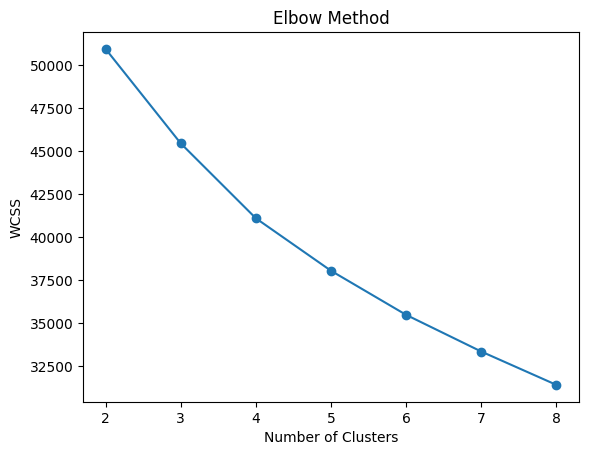

In [34]:
wcss = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,9), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [35]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Added n_init to suppress warning
labels = kmeans.fit_predict(X_pca)
df["User_Segment"] = labels # Assign labels to a new column in df

print("Silhouette:", silhouette_score(X_pca, labels))

Silhouette: 0.5642989789654846


In [36]:
cluster_profile = df.groupby("User_Segment")[features].mean()
print(cluster_profile)

              Daily_Energy_Consumption_kWh  Monthly_Electricity_Bill_PKR  \
User_Segment                                                               
0                                13.994321                  20382.505340   
1                                13.939661                  11253.609632   
2                                13.658444                  24231.927152   
3                                13.833401                  20923.617787   

              Monthly_Income_PKR  Load_Shedding_Hours  Avg_GHI_kWh_m2  
User_Segment                                                           
0                  109935.942172             6.515238        5.592324  
1                  151501.902531             6.476331        5.606441  
2                   29982.410596             6.713576        5.569421  
3                   52784.668703             6.418873        5.615193  


In [37]:
segment_names = {
    0: "Middle-Income Balanced Users",
    1: "High-Income Cost-Aware Users",
    2: "Low-Income High-Burden Users",
    3: "Lower-Middle Income Users"
}

df["Segment_Name"] = df["User_Segment"].map(segment_names)





In [38]:
df["Expected_Daily_Generation_kWh"] = (
    df["Avg_GHI_kWh_m2"] *
    df["Daily_Energy_Consumption_kWh"] /
    df["Daily_Energy_Consumption_kWh"].mean()
)

df.groupby("Segment_Name")["Expected_Daily_Generation_kWh"].mean()


,Expected_Daily_Generation_kWh
Segment_Name,
High-Income Cost-Aware Users,5.610939
Low-Income High-Burden Users,5.459084
Lower-Middle Income Users,5.579464
Middle-Income Balanced Users,5.611962


In [39]:
recommendations = {
    "Middle-Income Balanced Users": {
        "System_Type": "On-Grid",
        "Recommended_Size_kW": "3–4 kW",
        "Battery": "Not Required",
        "Advice": "On-grid solar is sufficient to reduce electricity bills at low cost."
    },
    "High-Income Cost-Aware Users": {
        "System_Type": "Hybrid",
        "Recommended_Size_kW": "4–5 kW",
        "Battery": "Optional",
        "Advice": "Hybrid system provides long-term savings and reliability."
    },
    "Low-Income High-Burden Users": {
        "System_Type": "On-Grid",
        "Recommended_Size_kW": "2–3 kW",
        "Battery": "Not Recommended",
        "Advice": "Small on-grid system with subsidy or installment is recommended."
    },
    "Lower-Middle Income Users": {
        "System_Type": "Hybrid",
        "Recommended_Size_kW": "3–4 kW",
        "Battery": "Small Backup",
        "Advice": "Hybrid system balances affordability and power backup."
    }
}


In [40]:
def get_user_recommendation(user_segment, expected_generation):
    rec = recommendations[user_segment]

    return {
        "User Segment": user_segment,
        "Expected Daily Generation (kWh)": round(expected_generation, 2),
        "Recommended System Type": rec["System_Type"],
        "Battery Requirement": rec["Battery"],
        "Personalized Advice": rec["Advice"]
    }


In [41]:
import pickle

with open("solar_user_segmentation.pkl", "wb") as f:
    pickle.dump({
        "normalizer": normalizer,
        "pca": pca,
        "kmeans": kmeans,
        "features": features,
        "segment_names": segment_names,
        "recommendations": recommendations
    }, f)


In [42]:
with open("solar_user_segmentation.pkl", "rb") as f:
    model_data = pickle.load(f)

normalizer_loaded = model_data["normalizer"]
pca_loaded = model_data["pca"]
kmeans_loaded = model_data["kmeans"]
features_loaded = model_data["features"]
segment_names_loaded = model_data["segment_names"]
recommendations_loaded = model_data["recommendations"]


# ***Final Output***

In [43]:
import pandas as pd
import numpy as np
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

city_ghi_map = {
    "lahore": 5.6,
    "karachi": 6.0,
    "islamabad": 5.4,
    "peshawar": 5.7,
    "quetta": 6.5,
    "multan": 6.2,
    "hyderabad": 6.1,
    "bahawalpur": 6.3
}

with open("solar_user_segmentation.pkl", "rb") as f:
    segmentation_data = pickle.load(f)

normalizer = segmentation_data["normalizer"]
pca = segmentation_data["pca"]
kmeans = segmentation_data["kmeans"]
features = segmentation_data["features"]
segment_names = segmentation_data["segment_names"]
recommendations = segmentation_data["recommendations"]

gb_size = joblib.load("solar_size_model.pkl")
gb_cost = joblib.load("solar_cost_model.pkl")

le_city = joblib.load("city_encoder.pkl")
le_location = joblib.load("location_encoder.pkl")
decision_encoders = joblib.load("decision_encoders.pkl")

print("All models loaded successfully")

X2 = df2[
    [
        'Weather_Condition_Index',
        'Load_Shedding_Hours',
        'Monthly_Electricity_Bill_PKR',
        'Avg_GHI_kWh_m2',
        'Monthly_Income_PKR'
    ]
]
y2 = df2['Solar_Purchase_Conclusion_enc']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

gb_decision = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)
gb_decision.fit(X2_train, y2_train)

print("Feasibility model trained")

default_city = df1['city'].mode()[0]
default_location_code = df1['location_code'].mode()[0]
default_solar_irradiance_kwh_per_m2_overall = df1['solar_irradiance_kwh_per_m2'].median()
default_sun_hours_overall = df1['sun_hours'].median()
default_avg_temp_c_overall = df1['avg_temp_c'].median()

city_info = df1.groupby('city').agg(
    location_code=('location_code', lambda x: x.mode()[0]),
    mean_solar_irradiance=('solar_irradiance_kwh_per_m2', 'mean'),
    mean_sun_hours=('sun_hours', 'mean'),
    mean_avg_temp_c=('avg_temp_c', 'mean')
).reset_index()

city_info['location_code_encoded'] = le_location.transform(city_info['location_code'])

city_to_location_code_map = dict(zip(city_info['city'], city_info['location_code_encoded']))
city_to_mean_irradiance_map = dict(zip(city_info['city'], city_info['mean_solar_irradiance']))
city_to_mean_sun_hours_map = dict(zip(city_info['city'], city_info['mean_sun_hours']))
city_to_mean_avg_temp_c_map = dict(zip(city_info['city'], city_info['mean_avg_temp_c']))

region_weather_info = df2.groupby('Region')['Weather_Condition_Index'].mean().reset_index()
city_to_mean_weather_map = dict(zip(region_weather_info['Region'], region_weather_info['Weather_Condition_Index']))

default_region = df2['Region'].mode()[0]
default_weather_condition_index_overall = df2['Weather_Condition_Index'].median()

def get_user_inputs():
    print("\n--- Enter User Details ---")

    city = input("City: ").strip()
    daily_energy = float(input("Daily Energy Consumption (kWh): "))
    roof_area = float(input("Roof Area (sqm): "))
    load_shedding = float(input("Load Shedding Hours (per day): "))
    monthly_income = float(input("Monthly Income (PKR): "))
    monthly_bill = float(input("Monthly Electricity Bill (PKR): "))

    # ---------- Encoding & Derivation ----------
    try:
        city_encoded = le_city.transform([city])[0]
    except:
        city_encoded = le_city.transform([default_city])[0]

    location_code_encoded = city_to_location_code_map.get(
        city,
        le_location.transform([default_location_code])[0]
    )

    solar_irradiance = city_to_mean_irradiance_map.get(
        city,
        default_solar_irradiance_kwh_per_m2_overall
    )

    sun_hours = city_to_mean_sun_hours_map.get(city, default_sun_hours_overall)
    avg_temp_c = city_to_mean_avg_temp_c_map.get(city, default_avg_temp_c_overall)

    weather_condition_index = city_to_mean_weather_map.get(
        city,
        default_weather_condition_index_overall
    )

    return {
        "city": city.lower(),
        "city_encoded": city_encoded,
        "location_code_encoded": location_code_encoded,
        "daily_energy_consumption_kwh": daily_energy,
        "roof_area_sqm": roof_area,
        "load_shedding_hours": load_shedding,
        "monthly_income_pkr": monthly_income,
        "monthly_electricity_bill_pkr": monthly_bill,
        "solar_irradiance_kwh_per_m2": solar_irradiance,
        "sun_hours": sun_hours,
        "avg_temp_c": avg_temp_c,
        "weather_condition_index": weather_condition_index
    }

def run_segmentation(user):
    avg_ghi = city_ghi_map.get(user["city"], 5.8)

    df = pd.DataFrame([{
        "Daily_Energy_Consumption_kWh": user["daily_energy_consumption_kwh"],
        "Monthly_Electricity_Bill_PKR": user["monthly_electricity_bill_pkr"],
        "Monthly_Income_PKR": user["monthly_income_pkr"],
        "Load_Shedding_Hours": user["load_shedding_hours"],
        "Avg_GHI_kWh_m2": avg_ghi
    }])

    X_norm = normalizer.transform(df[features])
    X_pca = pca.transform(X_norm)
    cluster = kmeans.predict(X_pca)[0]

    segment = segment_names[cluster]
    rec = recommendations[segment]

    expected_gen = user["roof_area_sqm"] * avg_ghi * 0.18

    print("\n--- USER SEGMENTATION ---")
    print(f"Segment: {segment}")
    print(f"Expected Daily Generation: {expected_gen:.2f} kWh")
    print(f"System Type: {rec['System_Type']}")
    print(f"Battery: {rec['Battery']}")
    print(f"Advice: {rec['Advice']}")


def run_size_cost_feasibility(user):

    df_size_cost = pd.DataFrame([{
        'city_encoded': user['city_encoded'],
        'location_code_encoded': user['location_code_encoded'],
        'daily_energy_consumption_kwh': user['daily_energy_consumption_kwh'],
        'roof_area_sqm': user['roof_area_sqm'],
        'load_shedding_hours': user['load_shedding_hours'],
        'solar_irradiance_kwh_per_m2': user['solar_irradiance_kwh_per_m2'],
        'sun_hours': user['sun_hours'],
        'avg_temp_c': user['avg_temp_c']
    }])

    size = gb_size.predict(df_size_cost)[0]
    cost = gb_cost.predict(df_size_cost)[0]

    print("\n--- SYSTEM SIZE & COST ---")
    print(f"Recommended Size: {size:.2f} kW")
    print(f"Estimated Cost: PKR {cost:,.0f}")

    # -------- FEASIBILITY (UNCHANGED) --------
    input_df_decision = pd.DataFrame([{
        'Weather_Condition_Index': user['weather_condition_index'],
        'Load_Shedding_Hours': user['load_shedding_hours'],
        'Monthly_Electricity_Bill_PKR': user['monthly_electricity_bill_pkr'],
        'Avg_GHI_kWh_m2': user['solar_irradiance_kwh_per_m2'],
        'Monthly_Income_PKR': user['monthly_income_pkr']
    }])

    feasibility_encoded = gb_decision.predict(input_df_decision)[0]

    le_solar_purchase = decision_encoders['Solar_Purchase_Conclusion']

    if 'Yes' in le_solar_purchase.classes_:
        yes_index = list(le_solar_purchase.classes_).index('Yes')
        feasibility_label = 'Yes' if feasibility_encoded == yes_index else 'No'
    else:
        feasibility_label = 'Yes' if feasibility_encoded == 1 else 'No'

    print("\n--- FEASIBILITY ---")
    print(f"Solar Installation Feasible? {feasibility_label}")

user_data = get_user_inputs()

run_segmentation(user_data)
run_size_cost_feasibility(user_data)


All models loaded successfully
Feasibility model trained

--- Enter User Details ---
City: Lahore
Daily Energy Consumption (kWh): 35
Roof Area (sqm): 40
Load Shedding Hours (per day): 3
Monthly Income (PKR): 250000
Monthly Electricity Bill (PKR): 25000

--- USER SEGMENTATION ---
Segment: High-Income Cost-Aware Users
Expected Daily Generation: 40.32 kWh
System Type: Hybrid
Battery: Optional
Advice: Hybrid system provides long-term savings and reliability.

--- SYSTEM SIZE & COST ---
Recommended Size: 7.72 kW
Estimated Cost: PKR 1,246,146

--- FEASIBILITY ---
Solar Installation Feasible? No


In [ ]:
import pandas as pd
import numpy as np
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

city_ghi_map = {
    "lahore": 5.6,
    "karachi": 6.0,
    "islamabad": 5.4,
    "peshawar": 5.7,
    "quetta": 6.5,
    "multan": 6.2,
    "hyderabad": 6.1,
    "bahawalpur": 6.3
}

with open("solar_user_segmentation.pkl", "rb") as f:
    segmentation_data = pickle.load(f)

normalizer = segmentation_data["normalizer"]
pca = segmentation_data["pca"]
kmeans = segmentation_data["kmeans"]
features = segmentation_data["features"]
segment_names = segmentation_data["segment_names"]
recommendations = segmentation_data["recommendations"]

gb_size = joblib.load("solar_size_model.pkl")
gb_cost = joblib.load("solar_cost_model.pkl")

le_city = joblib.load("city_encoder.pkl")
le_location = joblib.load("location_encoder.pkl")
decision_encoders = joblib.load("decision_encoders.pkl")

print("All models loaded successfully")

X2 = df2[
    [
        'Weather_Condition_Index',
        'Load_Shedding_Hours',
        'Monthly_Electricity_Bill_PKR',
        'Avg_GHI_kWh_m2',
        'Monthly_Income_PKR'
    ]
]
y2 = df2['Solar_Purchase_Conclusion_enc']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

gb_decision = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)
gb_decision.fit(X2_train, y2_train)

print("Feasibility model trained")

default_city = df1['city'].mode()[0]
default_location_code = df1['location_code'].mode()[0]
default_solar_irradiance_kwh_per_m2_overall = df1['solar_irradiance_kwh_per_m2'].median()
default_sun_hours_overall = df1['sun_hours'].median()
default_avg_temp_c_overall = df1['avg_temp_c'].median()

city_info = df1.groupby('city').agg(
    location_code=('location_code', lambda x: x.mode()[0]),
    mean_solar_irradiance=('solar_irradiance_kwh_per_m2', 'mean'),
    mean_sun_hours=('sun_hours', 'mean'),
    mean_avg_temp_c=('avg_temp_c', 'mean')
).reset_index()

city_info['location_code_encoded'] = le_location.transform(city_info['location_code'])

city_to_location_code_map = dict(zip(city_info['city'], city_info['location_code_encoded']))
city_to_mean_irradiance_map = dict(zip(city_info['city'], city_info['mean_solar_irradiance']))
city_to_mean_sun_hours_map = dict(zip(city_info['city'], city_info['mean_sun_hours']))
city_to_mean_avg_temp_c_map = dict(zip(city_info['city'], city_info['mean_avg_temp_c']))

region_weather_info = df2.groupby('Region')['Weather_Condition_Index'].mean().reset_index()
city_to_mean_weather_map = dict(zip(region_weather_info['Region'], region_weather_info['Weather_Condition_Index']))

default_region = df2['Region'].mode()[0]
default_weather_condition_index_overall = df2['Weather_Condition_Index'].median()

def get_user_inputs():
    print("\n--- Enter User Details ---")

    city = input("City: ").strip()
    daily_energy = float(input("Daily Energy Consumption (kWh): "))
    roof_area = float(input("Roof Area (sqm): "))
    load_shedding = float(input("Load Shedding Hours (per day): "))
    monthly_income = float(input("Monthly Income (PKR): "))
    monthly_bill = float(input("Monthly Electricity Bill (PKR): "))

    # ---------- Encoding & Derivation ----------
    try:
        city_encoded = le_city.transform([city])[0]
    except:
        city_encoded = le_city.transform([default_city])[0]

    location_code_encoded = city_to_location_code_map.get(
        city,
        le_location.transform([default_location_code])[0]
    )

    solar_irradiance = city_to_mean_irradiance_map.get(
        city,
        default_solar_irradiance_kwh_per_m2_overall
    )

    sun_hours = city_to_mean_sun_hours_map.get(city, default_sun_hours_overall)
    avg_temp_c = city_to_mean_avg_temp_c_map.get(city, default_avg_temp_c_overall)

    weather_condition_index = city_to_mean_weather_map.get(
        city,
        default_weather_condition_index_overall
    )

    return {
        "city": city.lower(),
        "city_encoded": city_encoded,
        "location_code_encoded": location_code_encoded,
        "daily_energy_consumption_kwh": daily_energy,
        "roof_area_sqm": roof_area,
        "load_shedding_hours": load_shedding,
        "monthly_income_pkr": monthly_income,
        "monthly_electricity_bill_pkr": monthly_bill,
        "solar_irradiance_kwh_per_m2": solar_irradiance,
        "sun_hours": sun_hours,
        "avg_temp_c": avg_temp_c,
        "weather_condition_index": weather_condition_index
    }

def run_segmentation(user):
    avg_ghi = city_ghi_map.get(user["city"], 5.8)

    df = pd.DataFrame([{
        "Daily_Energy_Consumption_kWh": user["daily_energy_consumption_kwh"],
        "Monthly_Electricity_Bill_PKR": user["monthly_electricity_bill_pkr"],
        "Monthly_Income_PKR": user["monthly_income_pkr"],
        "Load_Shedding_Hours": user["load_shedding_hours"],
        "Avg_GHI_kWh_m2": avg_ghi
    }])

    X_norm = normalizer.transform(df[features])
    X_pca = pca.transform(X_norm)
    cluster = kmeans.predict(X_pca)[0]

    segment = segment_names[cluster]
    rec = recommendations[segment]

    expected_gen = user["roof_area_sqm"] * avg_ghi * 0.18

    print("\n--- USER SEGMENTATION ---")
    print(f"Segment: {segment}")
    print(f"Expected Daily Generation: {expected_gen:.2f} kWh")
    print(f"System Type: {rec['System_Type']}")
    print(f"Battery: {rec['Battery']}")
    print(f"Advice: {rec['Advice']}")


def run_size_cost_feasibility(user):

    df_size_cost = pd.DataFrame([{
        'city_encoded': user['city_encoded'],
        'location_code_encoded': user['location_code_encoded'],
        'daily_energy_consumption_kwh': user['daily_energy_consumption_kwh'],
        'roof_area_sqm': user['roof_area_sqm'],
        'load_shedding_hours': user['load_shedding_hours'],
        'solar_irradiance_kwh_per_m2': user['solar_irradiance_kwh_per_m2'],
        'sun_hours': user['sun_hours'],
        'avg_temp_c': user['avg_temp_c']
    }])

    size = gb_size.predict(df_size_cost)[0]
    cost = gb_cost.predict(df_size_cost)[0]

    print("\n--- SYSTEM SIZE & COST ---")
    print(f"Recommended Size: {size:.2f} kW")
    print(f"Estimated Cost: PKR {cost:,.0f}")

    # -------- FEASIBILITY (UNCHANGED) --------
    input_df_decision = pd.DataFrame([{
        'Weather_Condition_Index': user['weather_condition_index'],
        'Load_Shedding_Hours': user['load_shedding_hours'],
        'Monthly_Electricity_Bill_PKR': user['monthly_electricity_bill_pkr'],
        'Avg_GHI_kWh_m2': user['solar_irradiance_kwh_per_m2'],
        'Monthly_Income_PKR': user['monthly_income_pkr']
    }])

    feasibility_encoded = gb_decision.predict(input_df_decision)[0]

    le_solar_purchase = decision_encoders['Solar_Purchase_Conclusion']

    if 'Yes' in le_solar_purchase.classes_:
        yes_index = list(le_solar_purchase.classes_).index('Yes')
        feasibility_label = 'Yes' if feasibility_encoded == yes_index else 'No'
    else:
        feasibility_label = 'Yes' if feasibility_encoded == 1 else 'No'

    print("\n--- FEASIBILITY ---")
    print(f"Solar Installation Feasible? {feasibility_label}")

user_data = get_user_inputs()

run_segmentation(user_data)
run_size_cost_feasibility(user_data)

All models loaded successfully
Feasibility model trained

--- Enter User Details ---
City: Karachi
Daily Energy Consumption (kWh): 15
Roof Area (sqm): 30
Load Shedding Hours (per day): 6
Monthly Income (PKR): 60000
Monthly Electricity Bill (PKR): 3000

--- USER SEGMENTATION ---
Segment: High-Income Cost-Aware Users
Expected Daily Generation: 32.40 kWh
System Type: Hybrid
Battery: Optional
Advice: Hybrid system provides long-term savings and reliability.

--- SYSTEM SIZE & COST ---
Recommended Size: 3.47 kW
Estimated Cost: PKR 553,694

--- FEASIBILITY ---
Solar Installation Feasible? No
